# Stage A - Training the Convolutional VAE
Train the healer network to reconstruct clean images from noisy ImageNet-100 inputs.

In [1]:
import sys
import os
from pathlib import Path

# Resolve project root robustly for notebook execution.
candidates = [
    Path('C:/Users/Akash/Desktop/SelfHealingNN'),
    Path.cwd(),
    Path.cwd().parent,
    Path.home() / 'Desktop' / 'SelfHealingNN',
]

current = Path.cwd()
for _ in range(8):
    candidates.append(current)
    current = current.parent

project_root = None
for candidate in candidates:
    candidate = candidate.resolve()
    if (candidate / 'src').exists() and (candidate / 'configs').exists():
        project_root = candidate
        break

if project_root is None:
    raise RuntimeError(f"Could not resolve project root. cwd={Path.cwd()}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

os.chdir(project_root)
print(f"Project root: {project_root}")
print(f"Working directory: {os.getcwd()}")

Project root: C:\Users\Akash\Desktop\SelfHealingNN
Working directory: C:\Users\Akash\Desktop\SelfHealingNN


In [2]:
from pathlib import Path
import importlib
import yaml
import torch
import matplotlib.pyplot as plt
from torchinfo import summary

import src.dataset as dataset_module
import src.conv_vae as conv_vae_module
import src.train_vae as train_vae_module
import src.evaluate as evaluate_module

# Reload modules so notebook always uses latest source edits.
importlib.reload(dataset_module)
importlib.reload(conv_vae_module)
importlib.reload(train_vae_module)
importlib.reload(evaluate_module)

get_dataloaders = dataset_module.get_dataloaders
ConvVAE = conv_vae_module.ConvVAE
vae_loss = conv_vae_module.vae_loss
train_vae = train_vae_module.train_vae
compute_psnr = evaluate_module.compute_psnr
compute_ssim = evaluate_module.compute_ssim

In [3]:
config_path = project_root / 'configs' / 'config.yaml'
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

requested_device = config.get('training', {}).get('device', 'cuda')
if str(requested_device).startswith('cuda') and torch.cuda.is_available():
    device = 'cuda'
    torch.backends.cudnn.benchmark = True
else:
    device = 'cpu'

model = ConvVAE(latent_dim=config['vae']['latent_dim']).to(device)
print(f"Using device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
model

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


ConvVAE(
  (encoder): ConvEncoder(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
      (3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.2, inplace=True)
      (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): LeakyReLU(negative_slope=0.2, inplace=True)
      (9): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (10): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (flatten): Flatten(start_d

In [4]:
summary(model, input_size=(1, 3, 224, 224), depth=3)

Layer (type:depth-idx)                   Output Shape              Param #
ConvVAE                                  [1, 3, 224, 224]          --
├─ConvEncoder: 1-1                       [1, 256]                  --
│    └─Sequential: 2-1                   [1, 512, 14, 14]          --
│    │    └─Conv2d: 3-1                  [1, 64, 112, 112]         3,136
│    │    └─BatchNorm2d: 3-2             [1, 64, 112, 112]         128
│    │    └─LeakyReLU: 3-3               [1, 64, 112, 112]         --
│    │    └─Conv2d: 3-4                  [1, 128, 56, 56]          131,200
│    │    └─BatchNorm2d: 3-5             [1, 128, 56, 56]          256
│    │    └─LeakyReLU: 3-6               [1, 128, 56, 56]          --
│    │    └─Conv2d: 3-7                  [1, 256, 28, 28]          524,544
│    │    └─BatchNorm2d: 3-8             [1, 256, 28, 28]          512
│    │    └─LeakyReLU: 3-9               [1, 256, 28, 28]          --
│    │    └─Conv2d: 3-10                 [1, 512, 14, 14]          2,

In [5]:
def loss_fn(recon, target, mu, logvar, beta):
    total, parts = vae_loss(recon, target, mu, logvar, beta=beta)
    return total, parts

loss_fn

<function __main__.loss_fn(recon, target, mu, logvar, beta)>

In [6]:
import inspect

# Set to True only when you intentionally want to ignore old checkpoints.
force_fresh_start = False

dataset_root = Path(config['dataset']['root'])
if not dataset_root.is_absolute():
    dataset_root = (project_root / dataset_root).resolve()

checkpoint_dir = project_root / 'models' / 'checkpoints' / 'vae'
latest_ckpt = checkpoint_dir / 'latest.pt'
if force_fresh_start and latest_ckpt.exists():
    latest_ckpt.unlink()

train_loader, val_loader, test_loader = get_dataloaders(
    root=str(dataset_root),
    image_size=config['dataset']['image_size'],
    batch_size=config['vae']['batch_size'],
    train_split=config['dataset']['train_split'],
    num_workers=config['training']['num_workers'],
    noisy=True,
    noise_type='gaussian',
    noise_params={'std': config['noise']['gaussian_std']}
)

sig = inspect.signature(train_vae)
if 'checkpoint_dir' not in sig.parameters:
    raise RuntimeError('Outdated train_vae loaded in kernel. Re-run Cell 3 (imports) or restart kernel and run all.')

use_amp = bool(config['training'].get('amp', True)) and not bool(config['vae'].get('disable_amp_until_stable', False))
auto_resume = bool(config['training'].get('auto_resume', True)) and not force_fresh_start

history = train_vae(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=config['vae']['epochs'],
    learning_rate=config['vae']['learning_rate'],
    beta=config['vae']['beta'],
    save_path=str(project_root / 'models' / 'conv_vae_best.pth'),
    patience=config['training']['early_stopping_patience'],
    checkpoint_dir=str(checkpoint_dir),
    checkpoint_interval=int(config['training'].get('checkpoint_interval', 2)),
    auto_resume=auto_resume,
    use_amp=use_amp,
    grad_clip_norm=float(config['training'].get('grad_clip_norm', 1.0)),
    denormalize_targets=bool(config['vae'].get('denormalize_targets', True)),
)

print(f"Checkpoint directory: {checkpoint_dir}")
print(f"Auto resume: {auto_resume}")
print(f"AMP enabled: {use_amp}")
print(f"Fresh start forced: {force_fresh_start}")

C:\Users\Akash\Desktop\SelfHealingNN\src\train_vae.py:145: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resume_checkpoint, map_location=device)


[VAE] Resuming from epoch 39 (latest.pt).


Epoch 039 | recon_loss=0.0295/0.0297 | kl_loss=0.0360/0.0351 | total_loss=0.0367/0.0367


Epoch 040 | recon_loss=0.0295/0.0296 | kl_loss=0.0360/0.0356 | total_loss=0.0367/0.0367


Epoch 041 | recon_loss=0.0295/0.0296 | kl_loss=0.0360/0.0354 | total_loss=0.0367/0.0367


...

Epoch 046 | recon_loss=0.0294/0.0294 | kl_loss=0.0361/0.0359 | total_loss=0.0367/0.0366


Epoch 047 | recon_loss=0.0294/0.0296 | kl_loss=0.0360/0.0354 | total_loss=0.0367/0.0366


Epoch 048 | recon_loss=0.0294/0.0296 | kl_loss=0.0360/0.0354 | total_loss=0.0367/0.0367


Epoch 049 | recon_loss=0.0294/0.0295 | kl_loss=0.0361/0.0358 | total_loss=0.0367/0.0366


Epoch 050 | recon_loss=0.0294/0.0296 | kl_loss=0.0361/0.0355 | total_loss=0.0367/0.0367
Checkpoint directory: C:\Users\Akash\Desktop\SelfHealingNN\models\checkpoints\vae
Auto resume: True
AMP enabled: False
Fresh start forced: False


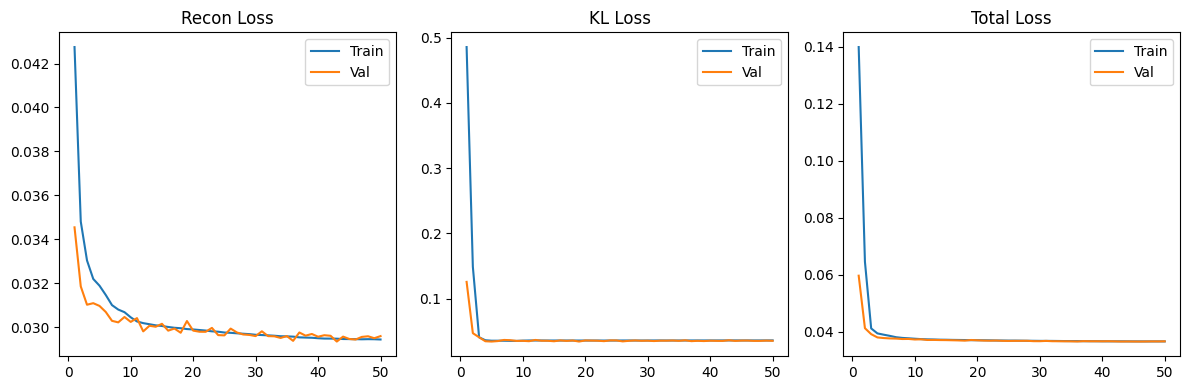

In [10]:
epochs = range(1, len(history['train_total']) + 1)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(epochs, history['train_recon'], label='Train')
plt.plot(epochs, history['val_recon'], label='Val')
plt.title('Recon Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, history['train_kl'], label='Train')
plt.plot(epochs, history['val_kl'], label='Val')
plt.title('KL Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, history['train_total'], label='Train')
plt.plot(epochs, history['val_total'], label='Val')
plt.title('Total Loss')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\Akash\AppData\Local\Temp\ipykernel_6804\2549261522.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(str(project_root / 'models' 

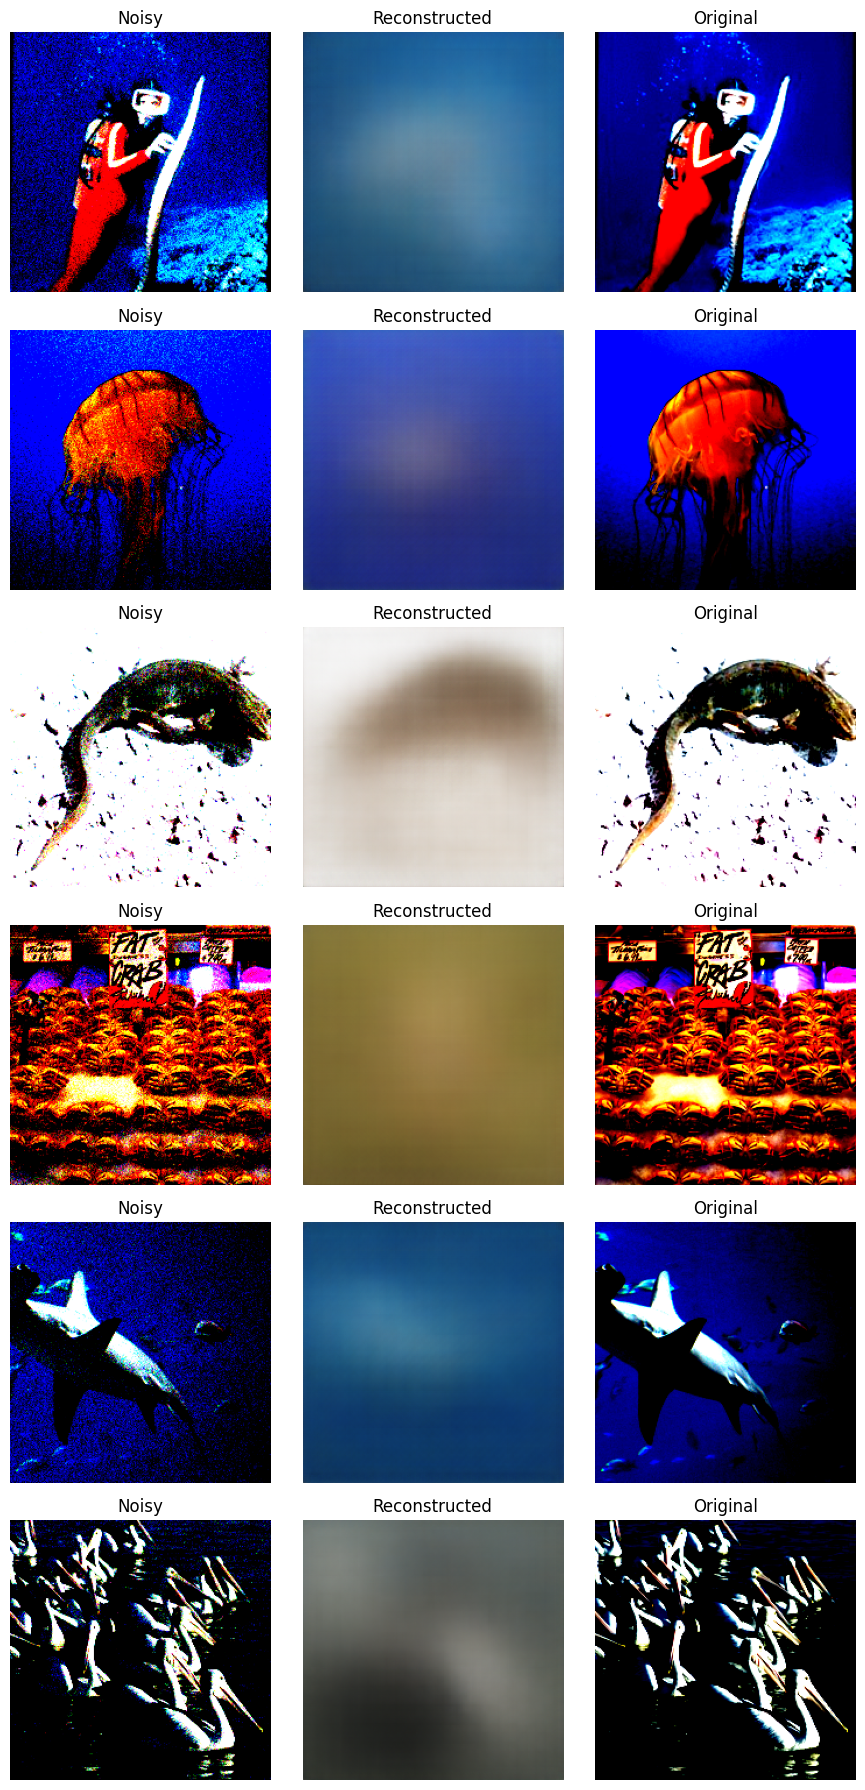

In [8]:
model.load_state_dict(torch.load(str(project_root / 'models' / 'conv_vae_best.pth'), map_location=device))
model.eval()

noisy, clean, _ = next(iter(test_loader))
noisy = noisy.to(device)
clean = clean.to(device)
with torch.no_grad():
    recon, _, _ = model(noisy)

n = min(6, noisy.size(0))
fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
for i in range(n):
    axes[i, 0].imshow(noisy[i].detach().cpu().permute(1, 2, 0).numpy(), vmin=-2, vmax=2)
    axes[i, 0].set_title('Noisy')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(recon[i].detach().cpu().permute(1, 2, 0).numpy())
    axes[i, 1].set_title('Reconstructed')
    axes[i, 1].axis('off')
    axes[i, 2].imshow(clean[i].detach().cpu().permute(1, 2, 0).numpy(), vmin=-2, vmax=2)
    axes[i, 2].set_title('Original')
    axes[i, 2].axis('off')
plt.tight_layout()
plt.show()

In [11]:
psnr_values = [compute_psnr(clean[i], recon[i]) for i in range(min(16, clean.size(0)))]
ssim_values = [compute_ssim(clean[i], recon[i]) for i in range(min(16, clean.size(0)))]
print('Avg PSNR:', sum(psnr_values) / len(psnr_values))
print('Avg SSIM:', sum(ssim_values) / len(ssim_values))

Avg PSNR: 12.722022411539703
Avg SSIM: 0.005571292480453849


## Summary
The ConvVAE healer is trained, tracked with reconstruction and KL losses, and validated through qualitative reconstructions plus PSNR/SSIM metrics.